## **PROJECT: Lasso Regression with Feature Selection**
#### **Objective**
Show how Lasso regression improves model by removing irrelevant features and reducing overfitting.

---

### **Import Libraries**
---

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error,r2_score

### **Load Dataset**
---

In [100]:
data = load_diabetes()

X = data.data
y = data.target

df = pd.DataFrame(X,columns=data.feature_names)
df["target"] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### **Train - Test Split**
---

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### **Feature Scaling**
---

In [102]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **MODEL 1: Linear Regression**
---

In [103]:
lr_model = LinearRegression()

lr_model.fit(X_train,y_train)

lr_y_pred = lr_model.predict(X_test)

print("Linear MSE: ",mean_squared_error(y_test,lr_y_pred))
print("Linear R2: ",r2_score(y_test,lr_y_pred))

Linear MSE:  2900.193628493482
Linear R2:  0.4526027629719195


### **Model 2: Lasso + Hyperparameter Tuning**
---

In [104]:
params = {
    "alpha":[0.0001,0.001,0.01,0.1,1,10,100]
}

grid = GridSearchCV(Lasso(),params,cv=5,scoring="r2")
grid.fit(X_train,y_train)


best_model = grid.best_estimator_

print("Best alpha: ",grid.best_params_["alpha"])

Best alpha:  1


### **Evaluation**
---

In [105]:
Lo_y_pred = best_model.predict(X_test)

print("Lasso MSE: ",mean_squared_error(y_test,Lo_y_pred))
print("Lasso R2: ",r2_score(y_test,Lo_y_pred))

Lasso MSE:  2824.568094049959
Lasso R2:  0.46687670944102466


### **Feature Selection**
---

In [106]:
coefficients = best_model.coef_
feature_names = df.columns[:-1]
for name,coeff in zip(feature_names,coefficients):
    print(name," : ",coeff)

age  :  0.6870321189342101
sex  :  -9.297519041249911
bmi  :  26.219224821372144
bp  :  15.657313572919811
s1  :  -8.228171802431133
s2  :  -0.0
s3  :  -9.024087140076437
s4  :  3.4208605902184197
s5  :  22.636465325281883
s6  :  2.098647124874425


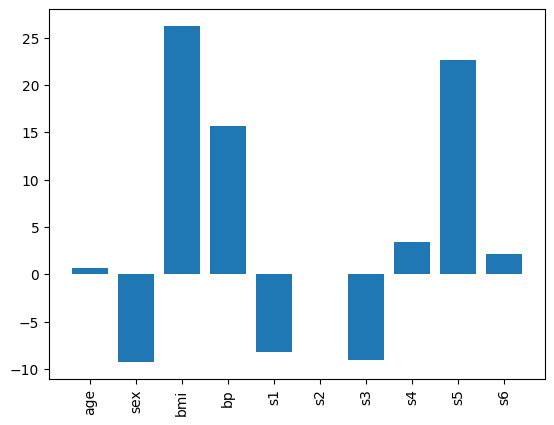

In [110]:
plt.bar(feature_names,coefficients)
plt.xticks(rotation=90)
plt.show()